# 02 — Feature Engineering V2

**Objetivo:** Transformar el dataset limpio en un dataset listo para modelado, preservando únicamente señales útiles disponibles al momento de llegada del lead y aplicando técnicas de codificación robustas para variables categóricas.

**Pasos de este notebook:**
1. Cargar el dataset limpio y preparar el entorno
2. Validar y eliminar variables redundantes si aún existen
3. Crear nuevas features temporales derivadas
4. Agrupar categorías de baja frecuencia
5. Separar Train/Test antes del encoding para evitar data leakage
6. Aplicar Target Encoding con Bayesian Smoothing y One-Hot Encoding selectivo
7. Exportar datasets finales para modelado

**Comparativa V1 vs V2:**
- **Versión 1:** El encoding categórico utilizaba One-Hot Encoding masivo y una técnica manual de "Encoding de contribución + Bayesian smoothing" que creaba 2 columnas por variable para evitar el sesgo de las categorías raras.
- **Versión 2 (Este notebook):** Se utiliza la librería estándar `category_encoders.TargetEncoder`, que aplica Bayesian Smoothing de forma robusta y reproducible. Esto evita la necesidad de crear 2 columnas por variable, simplifica el código, reduce la dimensionalidad y mantiene protección contra categorías de bajo volumen.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from category_encoders import TargetEncoder
from sklearn.model_selection import train_test_split

CLEAN_PATH = "../data/processed/leads_cleaned.csv"
df = pd.read_csv(CLEAN_PATH)

sns.set(style="whitegrid")
print(f"Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Columnas disponibles: {list(df.columns)}")

Dataset cargado: 58,546 filas x 12 columnas
Columnas disponibles: ['nombre_formulario', 'campana', 'origen_creacion', 'subtipo_interes', 'vehiculo_interes', 'concesionario', 'origen', 'mes_creacion', 'dia_creacion', 'hora_creacion', 'dia_semana_creacion', 'target']


## 1. Validar y eliminar features sin valor predictivo

En este paso verificamos si aún sobreviven columnas redundantes, de varianza nula o con riesgo de contaminar el modelado. Como el dataset ya viene de `00_data_engineering_v2_2025.ipynb`, aquí actuamos de forma defensiva: solo eliminamos columnas si todavía existen.

**Diferencias V1 vs V2:**
En la V1 parte de esta limpieza se resolvía más tarde y quedaba mezclada con el encoding. En la V2 dejamos este control explícito al inicio para que el pipeline sea más fácil de auditar y mantener.

In [2]:
cols_eliminar = ["anio_creacion", "subtipo_interes", "plataforma"]
cols_presentes = [c for c in cols_eliminar if c in df.columns]

if cols_presentes:
    df = df.drop(columns=cols_presentes)
    print(f"Columnas eliminadas: {cols_presentes}")
else:
    print("No había columnas redundantes adicionales por eliminar.")

print(f"Dataset tras validación inicial: {df.shape[0]:,} filas x {df.shape[1]} columnas")

Columnas eliminadas: ['subtipo_interes']
Dataset tras validación inicial: 58,546 filas x 11 columnas


## 2. Crear nuevas features derivadas

A partir de las variables temporales del dataset limpio, generamos señales más interpretables para el modelo. En particular:
- `es_fin_de_semana`: captura diferencias de comportamiento entre días hábiles y fines de semana.
- `franja_horaria`: resume la hora exacta en bloques comerciales más estables.

**Hallazgos esperados:**
Estas transformaciones suelen capturar mejor patrones operativos que la hora cruda, especialmente cuando el volumen de leads cambia por jornada.

**Diferencias V1 vs V2:**
En la V1 la señal horaria estaba degradada porque se derivaba desde una columna del sistema. En la V2 aprovechamos la hora real del cliente ya corregida en Data Engineering.

Nuevas features derivadas creadas exitosamente.


,count,mean
franja_horaria,,
tarde,20648,0.382168
noche,20307,0.342739
manana,10979,0.372074
madrugada,6612,0.318512


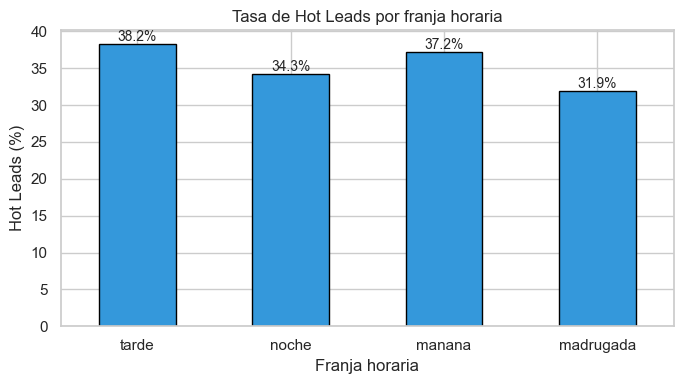

In [3]:
if "dia_semana_creacion" in df.columns:
    df["es_fin_de_semana"] = df["dia_semana_creacion"].isin(["sábado", "domingo"]).astype(int)

def clasificar_franja(hora):
    if 0 <= hora < 6:
        return "madrugada"
    elif 6 <= hora < 12:
        return "manana"
    elif 12 <= hora < 18:
        return "tarde"
    return "noche"

if "hora_creacion" in df.columns:
    df["franja_horaria"] = df["hora_creacion"].apply(clasificar_franja)

print("Nuevas features derivadas creadas exitosamente.")

if {"franja_horaria", "target"}.issubset(df.columns):
    resumen_franja = (
        df.groupby("franja_horaria")["target"]
        .agg(["count", "mean"])
        .sort_values("count", ascending=False)
    )
    display(resumen_franja)

    plt.figure(figsize=(7, 4))
    ax = (resumen_franja["mean"] * 100).plot(kind="bar", color="#3498db", edgecolor="black")
    plt.title("Tasa de Hot Leads por franja horaria")
    plt.ylabel("Hot Leads (%)")
    plt.xlabel("Franja horaria")
    plt.xticks(rotation=0)
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2, p.get_height()), ha="center", va="bottom", fontsize=10)
    plt.tight_layout()
    plt.show()

## 3. Agrupar categorías de baja frecuencia

Las categorías extremadamente raras generan ruido y pueden producir estimaciones inestables durante el encoding. Para reducir ese efecto, agrupamos en `otros` las categorías con frecuencia menor al 1% del dataset.

**Hallazgos esperados:**
Este paso suele reducir dispersión, mejorar robustez estadística y evitar que el encoder sobreinterprete categorías con muy pocos ejemplos.

**Diferencias V1 vs V2:**
En la V1 parte de esta robustez se intentaba recuperar después mediante columnas manuales de contribución. En la V2 reducimos el problema desde antes, agrupando categorías raras y luego aplicando Target Encoding.

,columna,categorias_originales,categorias_agrupadas,filas_reetiquetadas,categorias_finales
0,nombre_formulario,20,13,549,8
1,vehiculo_interes,23,12,1156,12
2,origen,25,16,188,10
3,campana,118,110,3061,9
4,concesionario,96,54,17708,43


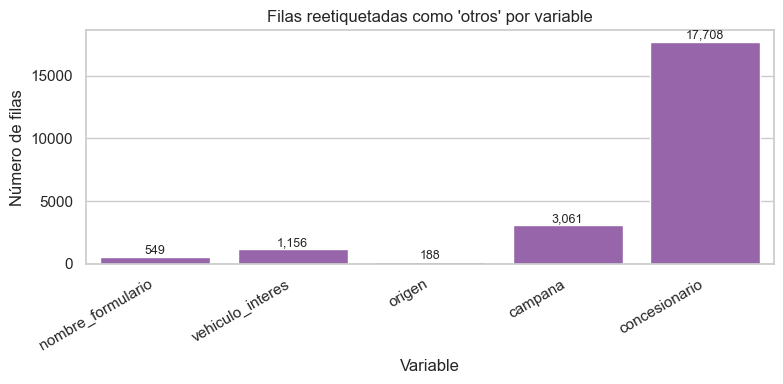

In [4]:
UMBRAL_PCT = 1.0
umbral_abs = int(len(df) * UMBRAL_PCT / 100)

cat_cols_agrupar = ["nombre_formulario", "vehiculo_interes", "origen", "campana", "concesionario"]
resumen_agrupacion = []

for col in cat_cols_agrupar:
    if col not in df.columns:
        continue

    vc = df[col].value_counts()
    bajas = vc[vc < umbral_abs].index
    filas_afectadas = int(df[col].isin(bajas).sum())

    if len(bajas) > 0:
        df.loc[df[col].isin(bajas), col] = "otros"

    resumen_agrupacion.append({
        "columna": col,
        "categorias_originales": int(vc.shape[0]),
        "categorias_agrupadas": int(len(bajas)),
        "filas_reetiquetadas": filas_afectadas,
        "categorias_finales": int(df[col].nunique()),
    })

resumen_agrupacion = pd.DataFrame(resumen_agrupacion)
display(resumen_agrupacion)

if not resumen_agrupacion.empty:
    plt.figure(figsize=(8, 4))
    ax = sns.barplot(data=resumen_agrupacion, x="columna", y="filas_reetiquetadas", color="#9b59b6")
    plt.title("Filas reetiquetadas como 'otros' por variable")
    plt.ylabel("Número de filas")
    plt.xlabel("Variable")
    plt.xticks(rotation=30, ha="right")
    for p in ax.patches:
        ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2, p.get_height()), ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()

## 4. Split Train/Test

Es crítico separar el dataset **antes** de aplicar cualquier encoding para evitar **data leakage**. Si calculáramos estadísticas sobre todo el dataset y luego dividiéramos, el modelo recibiría información indirecta del conjunto de prueba.

**Hallazgo esperado:**
Después del split, la proporción de Hot/Cold debe mantenerse casi igual en ambos conjuntos gracias a `stratify=y`.

**Diferencias V1 vs V2:**
En la V1 había más transformaciones manuales previas al modelado. En la V2 hacemos explícita esta frontera para que cualquier transformación supervisada ocurra exclusivamente sobre train.

In [5]:
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]:,} filas")
print(f"Test:  {X_test.shape[0]:,} filas")
print(f"Hot rate train: {y_train.mean()*100:.2f}%")
print(f"Hot rate test:  {y_test.mean()*100:.2f}%")

Train: 46,836 filas
Test:  11,710 filas
Hot rate train: 35.94%
Hot rate test:  35.94%


## 5. Bayesian Target Encoding (Reemplaza la lógica manual de V1)

### 5.1 ¿Por qué ya no usamos el "Encoding de contribución" manual?
En la V1, el paso de contribución + Bayesian smoothing creaba manualmente dos columnas por variable para evitar que categorías raras con tasas extremas confundieran al modelo.

En la V2 utilizamos **`category_encoders.TargetEncoder`** con el parámetro `smoothing`. Esta implementación aplica el mismo principio estadístico de suavizado Bayesiano, pero de forma más compacta, robusta y mantenible.

**Hallazgos esperados:**
- Menor dimensionalidad que en V1
- Menor complejidad de mantenimiento
- Menor riesgo de errores manuales en el cálculo de tasas suavizadas

**Diferencias V1 vs V2:**
V1 construía columnas derivadas manualmente. V2 delega esa responsabilidad en una librería especializada y ampliamente usada, manteniendo el control del leakage al entrenarla solo sobre `X_train`.

In [6]:
# Variables a codificar con Bayesian Smoothing
encode_cols = ["vehiculo_interes", "origen", "nombre_formulario", "campana", "concesionario"]
encode_cols = [c for c in encode_cols if c in X_train.columns]

# TargetEncoder aplica el Bayesian Smoothing automáticamente
encoder = TargetEncoder(cols=encode_cols, smoothing=100)

X_train_enc = encoder.fit_transform(X_train, y_train)
X_test_enc = encoder.transform(X_test)

print("Bayesian Target Encoding aplicado con éxito.")
print(f"Columnas con Target Encoding: {encode_cols}")

if encode_cols:
    preview_cols = encode_cols[: min(3, len(encode_cols))]
    display(X_train_enc[preview_cols].head())

Bayesian Target Encoding aplicado con éxito.
Columnas con Target Encoding: ['vehiculo_interes', 'origen', 'nombre_formulario', 'campana', 'concesionario']


,vehiculo_interes,origen,nombre_formulario
11717,0.449270,0.502637,0.671755
56193,0.268236,0.442875,0.344910
17584,0.119566,0.247445,0.344910
55266,0.368436,0.481837,0.344910
37416,0.309161,0.442875,0.344910


### 5.2 One-Hot Encoding para variables de baja cardinalidad

Las variables categóricas restantes, generalmente de baja cardinalidad, se codifican con One-Hot Encoding. Este enfoque conserva interpretabilidad sin inflar innecesariamente el número de columnas.

**Diferencias V1 vs V2:**
En la V1 el One-Hot tenía mucho más peso porque se aplicaba de forma más agresiva. En la V2 queda reservado para variables pequeñas, mientras que las variables con más categorías pasan por Target Encoding.

Columnas codificadas con One-Hot: ['origen_creacion', 'dia_semana_creacion', 'franja_horaria']


Dimensiones finales Train: (46836, 22)
Dimensiones finales Test:  (11710, 22)
Total de features finales: 22


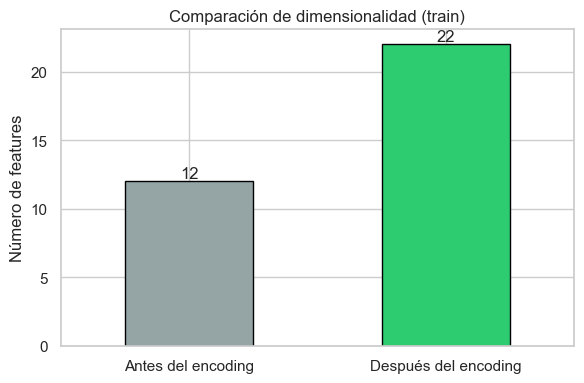

In [7]:
onehot_cols = list(X_train_enc.select_dtypes(include=["object"]).columns)

X_train_final = pd.get_dummies(X_train_enc, columns=onehot_cols, drop_first=True, dtype=int)
X_test_final = pd.get_dummies(X_test_enc, columns=onehot_cols, drop_first=True, dtype=int)

# Alinear columnas
X_test_final = X_test_final.reindex(columns=X_train_final.columns, fill_value=0)

print(f"Columnas codificadas con One-Hot: {onehot_cols}")
print(f"Dimensiones finales Train: {X_train_final.shape}")
print(f"Dimensiones finales Test:  {X_test_final.shape}")
print(f"Total de features finales: {X_train_final.shape[1]}")

plt.figure(figsize=(6, 4))
resumen_dim = pd.Series({
    "Antes del encoding": X_train.shape[1],
    "Después del encoding": X_train_final.shape[1],
})
ax = resumen_dim.plot(kind="bar", color=["#95a5a6", "#2ecc71"], edgecolor="black")
plt.title("Comparación de dimensionalidad (train)")
plt.ylabel("Número de features")
plt.xticks(rotation=0)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()), ha="center", va="bottom")
plt.tight_layout()
plt.show()

**Hallazgos de la codificación V2:**
La estrategia híbrida aplicada en este notebook logra un equilibrio útil entre densidad estadística, interpretabilidad y control del sobreajuste. Las variables de alta cardinalidad quedan resumidas en una sola señal numérica suavizada, mientras que las variables pequeñas conservan su estructura con One-Hot Encoding.

**Diferencias V1 vs V2:**
La V1 dependía más de ingeniería manual y generaba más columnas auxiliares. La V2 reduce complejidad, estandariza el pipeline y facilita que la inferencia en producción replique exactamente el mismo comportamiento.

## 6. Exportar datasets para modelado

Una vez finalizado el feature engineering, exportamos los conjuntos `X_train`, `X_test`, `y_train` y `y_test` para que el notebook de modelado pueda enfocarse únicamente en entrenamiento y evaluación.

**Diferencias V1 vs V2:**
En la V1 parte de estas transformaciones y validaciones quedaban más acopladas al modelado. En la V2 separamos responsabilidades: este notebook construye features; el siguiente entrena modelos.

In [8]:
import os

OUTPUT_DIR = "../data/processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

X_train_final.to_csv(f"{OUTPUT_DIR}/X_train_v2.csv", index=False)
X_test_final.to_csv(f"{OUTPUT_DIR}/X_test_v2.csv", index=False)
y_train.to_csv(f"{OUTPUT_DIR}/y_train_v2.csv", index=False)
y_test.to_csv(f"{OUTPUT_DIR}/y_test_v2.csv", index=False)

print("Archivos exportados exitosamente.")
print(f"X_train_v2.csv: {X_train_final.shape}")
print(f"X_test_v2.csv:  {X_test_final.shape}")
print(f"y_train_v2.csv: {y_train.shape}")
print(f"y_test_v2.csv:  {y_test.shape}")

Archivos exportados exitosamente.
X_train_v2.csv: (46836, 22)
X_test_v2.csv:  (11710, 22)
y_train_v2.csv: (46836,)
y_test_v2.csv:  (11710,)
